# 02 Clustering

One HDBSCAN label per session, on top of the table 01 wrote to `/data/work/sessions/sessions.parquet`. The label is what 03 stratifies the Kaplan-Meier curves on.

Only structural features go in, no command-string TF-IDF yet. `duration_sec`, `event_observed`, and `command_count` stay out: clustering on an outcome and then finding the clusters differ on that outcome is circular, not a finding.

Writes the result to `/data/work/sessions_clustered/sessions_clustered.parquet`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

sessions = pd.read_parquet("/data/work/sessions/sessions.parquet")
sessions.shape

(22511, 36)

## 1. Feature selection

Beyond the identifier/outcome split from 01, five columns come out because 01's correlation heatmap showed them at 1.0 with something else already kept:

- `n_login_success` duplicates `login_success` (the boolean already carries it).
- `unique_payloads` and `n_session_file_download` duplicate `download_count`.
- `n_log_closed` and `n_session_params` correlate at 0.996 with `command_count`, an excluded outcome. Keeping them would let clustering reconstruct command_count through the back door.

In [2]:
identifier_cols = ["session", "src_ip", "connect_time", "client_version", "client_kex"]
outcome_cols = ["duration_sec", "event_observed", "command_count"]
drop_cols = [
    "n_login_success",
    "unique_payloads", "n_session_file_download",
    "n_log_closed", "n_session_params",
]
feature_cols = [
    c for c in sessions.columns
    if c not in identifier_cols + outcome_cols + drop_cols
]
print(f"{len(feature_cols)} features")
feature_cols

23 features


['unique_usernames',
 'unique_passwords',
 'login_attempts',
 'login_success',
 'download_count',
 'client_version_freq',
 'client_kex_freq',
 'connect_hour_sin',
 'connect_hour_cos',
 'src_ip_sessions_same_day',
 'n_client_fingerprint',
 'n_client_kex',
 'n_client_malformed_packet',
 'n_client_size',
 'n_client_version',
 'n_command_chpasswd',
 'n_command_failed',
 'n_direct-tcpip_data',
 'n_direct-tcpip_ja4',
 'n_direct-tcpip_ja4h',
 'n_direct-tcpip_request',
 'n_login_failed',
 'n_session_file_upload']

## 2. Log1p and scale

Count-like columns are heavily right-skewed (a handful of sessions with 15+ commands next to thousands with 0-1), so they get `log1p` before scaling. `login_success` is already boolean, and the frequency/sin/cos columns are already bounded, so those three groups go straight to the scaler.

In [3]:
bounded_cols = [
    "login_success", "client_version_freq", "client_kex_freq",
    "connect_hour_sin", "connect_hour_cos",
]
count_cols = [c for c in feature_cols if c not in bounded_cols]

X = sessions[feature_cols].copy()
X[count_cols] = np.log1p(X[count_cols])
X["login_success"] = X["login_success"].astype(int)

Xs = StandardScaler().fit_transform(X.to_numpy())
Xs.shape

(22511, 23)

## 3. min_cluster_size sweep

Not decided up front. Sweeping and watching noise ratio and cluster count together; a value chosen without seeing this curve is a guess.

In [4]:
sweep_rows = []
for mcs in [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 300]:
    labels = HDBSCAN(min_cluster_size=mcs, copy=False).fit_predict(Xs)
    n_noise = int((labels == -1).sum())
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    sweep_rows.append({
        "min_cluster_size": mcs,
        "n_clusters": n_clusters,
        "noise_ratio": n_noise / len(labels),
    })

sweep = pd.DataFrame(sweep_rows)
sweep

,min_cluster_size,n_clusters,noise_ratio
0,5,588,0.030296
1,10,361,0.042157
2,15,245,0.056284
3,20,184,0.065879
4,30,125,0.080583
5,50,73,0.110035
6,75,54,0.123229
7,100,39,0.136333
8,150,31,0.087246
9,200,27,0.108303


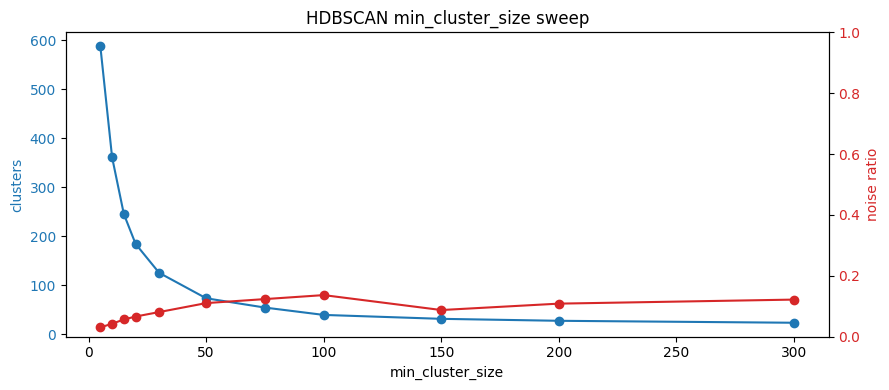

In [5]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sweep["min_cluster_size"], sweep["n_clusters"], marker="o", color="tab:blue")
ax1.set_xlabel("min_cluster_size")
ax1.set_ylabel("clusters", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sweep["min_cluster_size"], sweep["noise_ratio"], marker="o", color="tab:red")
ax2.set_ylabel("noise ratio", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 1)

ax1.set_title("HDBSCAN min_cluster_size sweep")
fig.tight_layout()
plt.show()

Cluster count falls from 588 at min_cluster_size=5 to 23 at 300, and noise wanders between 3% and 14% without settling. No part of the curve marks an obvious choice, which is itself a result: there is no scale at which this feature set produces a stable number of groups. Picking 100 as a round value in the middle, to see what the clusters are made of rather than as an answer. It is one constant to change and rerun.

In [6]:
MIN_CLUSTER_SIZE = 100

labels = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, copy=False).fit_predict(Xs)
sessions["cluster"] = labels
sessions["is_noise"] = labels == -1

sessions["cluster"].value_counts().sort_index()

cluster
-1     3069
 0      240
 1      150
 2      276
 3      461
 4      870
 5      588
 6      325
 7     1179
 8      158
 9      479
 10     779
 11     174
 12     699
 13     379
 14     306
 15     244
 16     306
 17     547
 18     794
 19    2388
 20    1999
 21     159
 22     564
 23     376
 24    1338
 25     991
 26     529
 27     159
 28     195
 29     128
 30     125
 31     172
 32     170
 33     530
 34     115
 35     119
 36     140
 37     141
 38     150
Name: count, dtype: int64

## 4. Cluster sizes

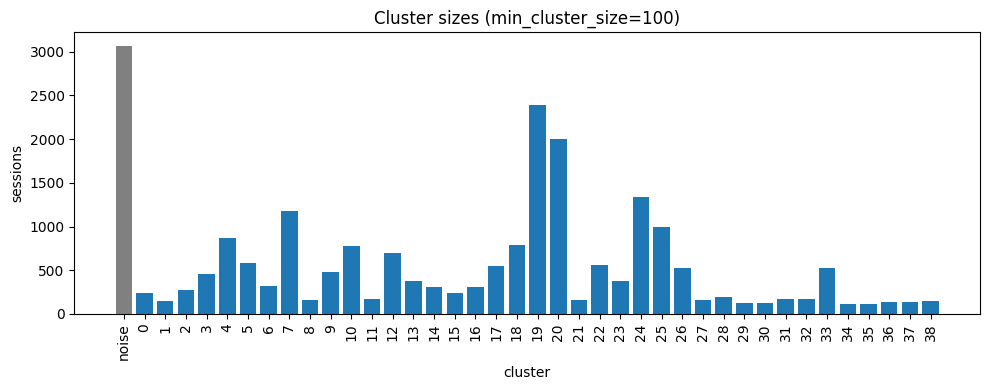

In [7]:
sizes = sessions["cluster"].value_counts().sort_index()
colors = ["gray" if c == -1 else "tab:blue" for c in sizes.index]
labels_x = ["noise" if c == -1 else str(c) for c in sizes.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(labels_x, sizes.values, color=colors)
ax.set_xlabel("cluster")
ax.set_ylabel("sessions")
ax.set_title(f"Cluster sizes (min_cluster_size={MIN_CLUSTER_SIZE})")
plt.xticks(rotation=90)
fig.tight_layout()
plt.show()

## 5. PCA scatter

Two components on the same standardized feature matrix the clustering ran on. Noise in gray, underneath the colored points so it does not hide them.

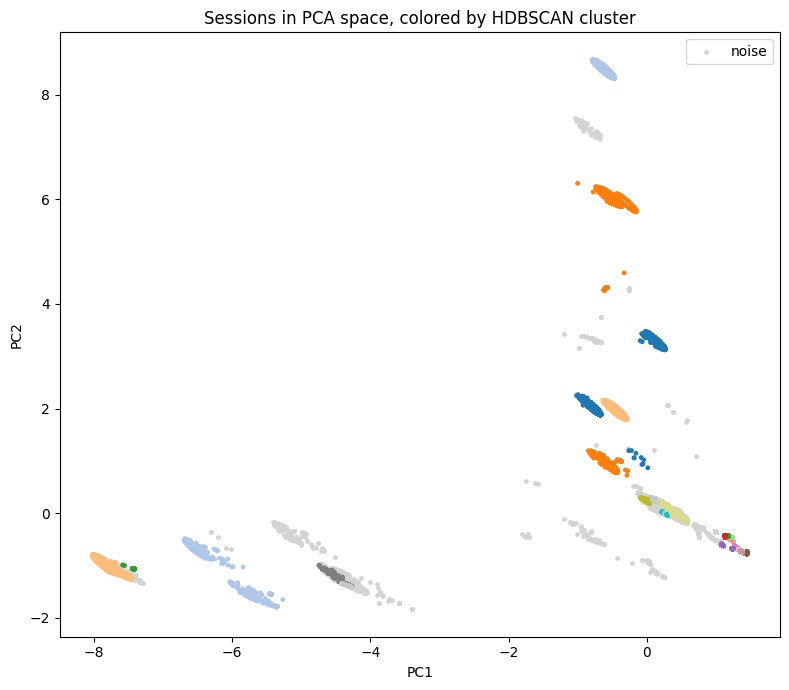

In [8]:
coords = PCA(n_components=2).fit_transform(Xs)
sessions["pca_1"] = coords[:, 0]
sessions["pca_2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))
noise_mask = sessions["is_noise"]
ax.scatter(
    sessions.loc[noise_mask, "pca_1"], sessions.loc[noise_mask, "pca_2"],
    s=6, color="lightgray", label="noise",
)
clustered = sessions.loc[~noise_mask]
sc = ax.scatter(
    clustered["pca_1"], clustered["pca_2"],
    s=6, c=clustered["cluster"], cmap="tab20",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Sessions in PCA space, colored by HDBSCAN cluster")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

If the clusters overlap into one blob here, that is PCA's linear projection losing the separation HDBSCAN found in the full feature space, not necessarily HDBSCAN being wrong. t-SNE on `Xs` would be the next thing to try before doubting the clustering itself.

## 6. Cluster x feature profile

Mean of each feature within a cluster, z-scored against the whole population (not just the clustered rows) so a cluster that is merely average reads as zero. Noise excluded, since it is not a cluster.

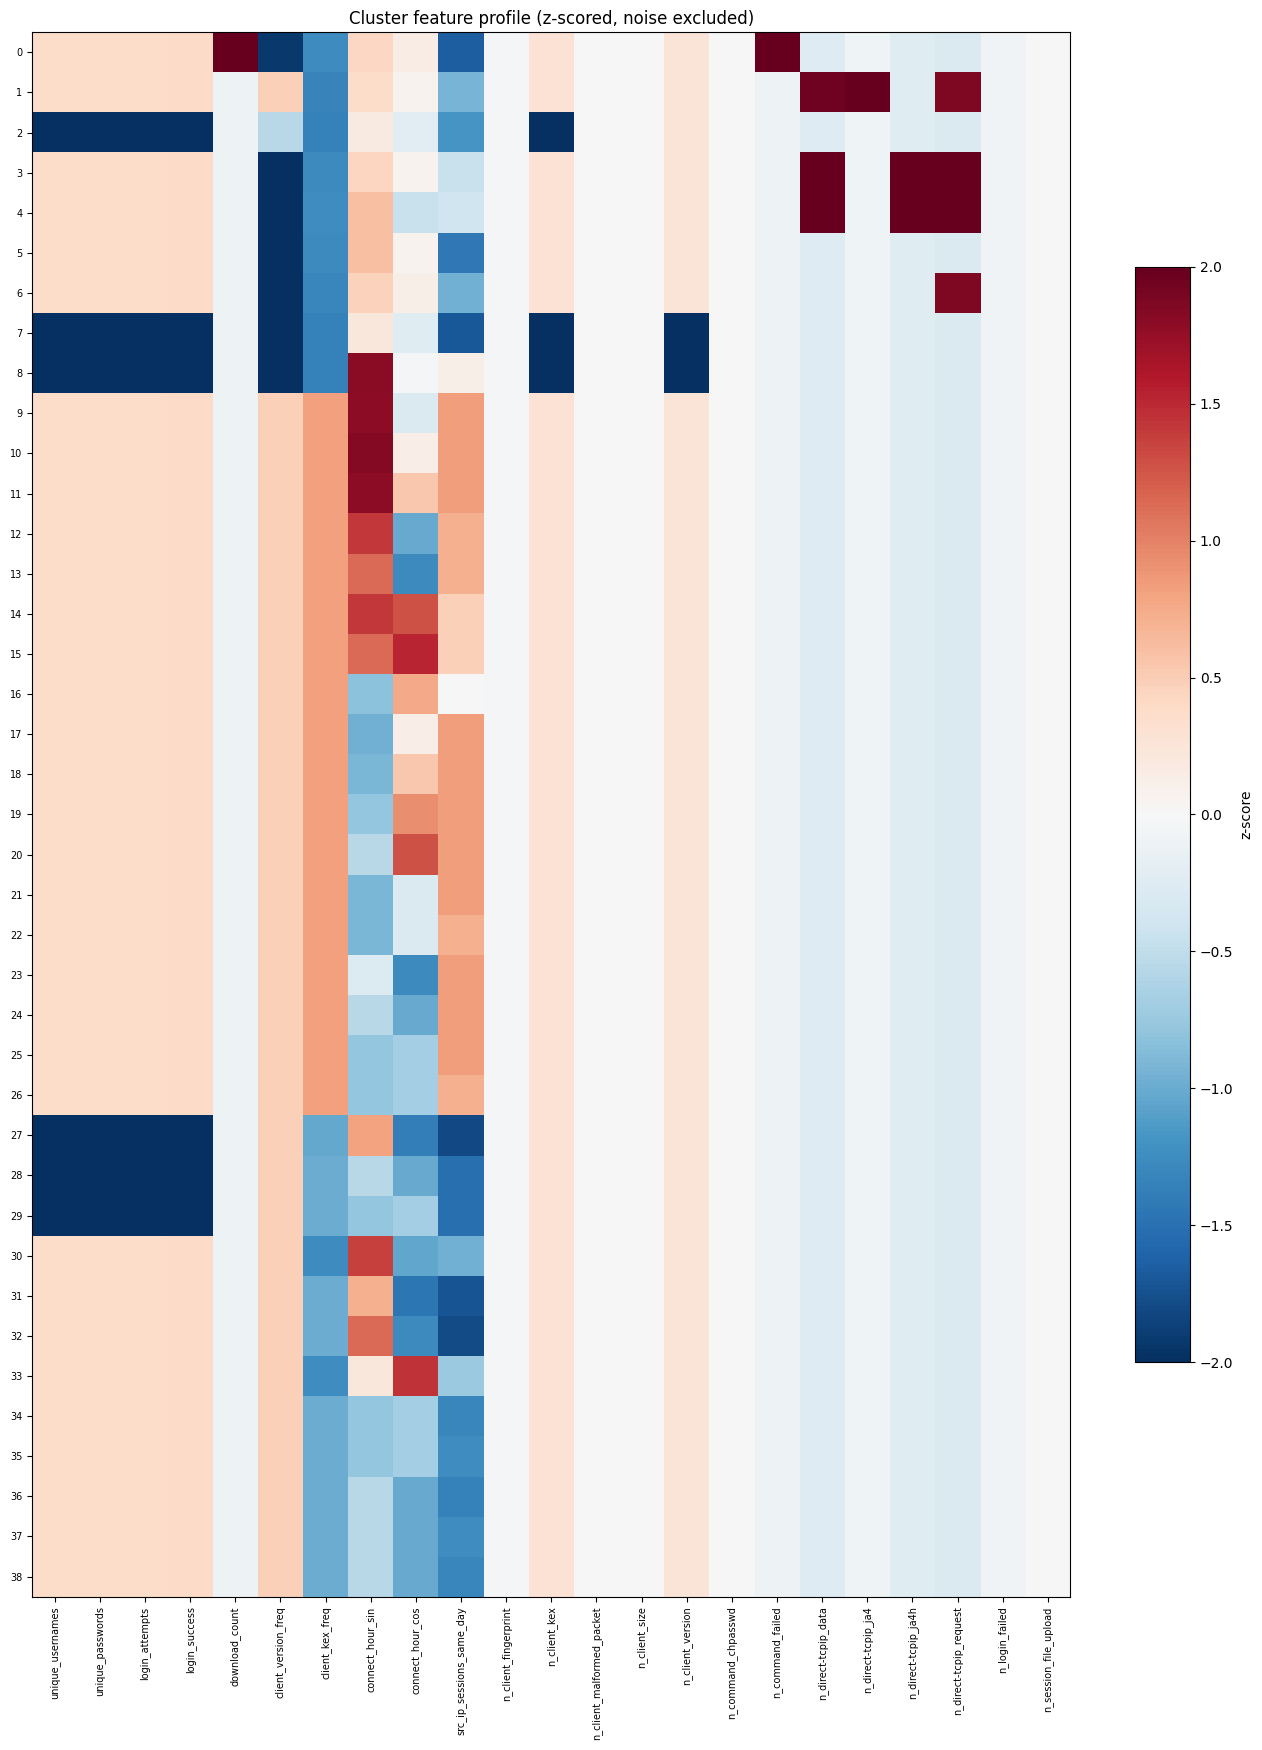

In [9]:
z = (X - X.mean()) / X.std()
z["cluster"] = sessions["cluster"].values
profile = z[z["cluster"] != -1].groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(0.5 * len(profile.columns) + 2, 0.4 * len(profile) + 2))
im = ax.imshow(profile.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(profile.columns)))
ax.set_xticklabels(profile.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(profile.index)))
ax.set_yticklabels(profile.index, fontsize=7)
fig.colorbar(im, shrink=0.7, label="z-score")
ax.set_title("Cluster feature profile (z-scored, noise excluded)")
fig.tight_layout()
plt.show()

## 7. Write out

In [10]:
from pathlib import Path

out_dir = Path("/data/work/sessions_clustered")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "sessions_clustered.parquet"
sessions.to_parquet(out_path, index=False)
print(f"wrote {len(sessions)} rows, {sessions['cluster'].nunique() - 1} clusters, "
      f"{sessions['is_noise'].mean():.1%} noise, to {out_path}")

wrote 22511 rows, 39 clusters, 13.6% noise, to /data/work/sessions_clustered/sessions_clustered.parquet


## 8. Retry: down-weighting connect hour

The bulk of sessions above (clusters 6-15 in the run before this one) turned out identical on every feature except `connect_hour_sin`/`connect_hour_cos`. HDBSCAN was mostly splitting the same "logged in, ran one command, hung up" behaviour into ten pieces by time of day, which is a real pattern but not the kind of difference this clustering is meant to surface.

First attempt: scale the two hour columns down after standardizing, instead of dropping them.

In [11]:
HOUR_COLS = ["connect_hour_sin", "connect_hour_cos"]
hour_idx = [feature_cols.index(c) for c in HOUR_COLS]

weight_rows = []
for w in [1.0, 0.5, 0.3, 0.1, 0.05, 0.01, 0.001, 0.0]:
    Xw = Xs.copy()
    Xw[:, hour_idx] *= w
    labels_w = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, copy=False).fit_predict(Xw)
    n_noise = int((labels_w == -1).sum())
    n_clusters = len(set(labels_w)) - (1 if -1 in labels_w else 0)
    weight_rows.append({"weight": w, "n_clusters": n_clusters, "noise_ratio": n_noise / len(labels_w)})

pd.DataFrame(weight_rows)

,weight,n_clusters,noise_ratio
0,1.000,39,0.136333
1,0.500,41,0.096753
2,0.300,43,0.099329
3,0.100,44,0.068811
4,0.050,45,0.055839
5,0.010,51,0.070632
6,0.001,52,0.071165
7,0.000,40,0.072676


Not a gradient. Weights from 1.0 down to 0.001 give 39 to 52 clusters, drifting up rather than down, and only an exact 0 brings it back to 39 with the noise ratio halved. The reason is structural rather than a tuning problem: within the bulk group every other feature is (near enough) constant, so no matter how small the scale factor, the hour columns are the only source of distance between those points and HDBSCAN still finds density structure along them. Scaling down was the plan going in, but the data says this one needs to be excluded from the metric entirely, not just down-weighted.

In [12]:
Xw = Xs.copy()
Xw[:, hour_idx] = 0.0

sweep2_rows = []
for mcs in [10, 15, 20, 30, 50, 75, 100, 150, 200, 300, 400, 500, 750]:
    labels_w = HDBSCAN(min_cluster_size=mcs, copy=False).fit_predict(Xw)
    n_noise = int((labels_w == -1).sum())
    n_clusters = len(set(labels_w)) - (1 if -1 in labels_w else 0)
    sweep2_rows.append({"min_cluster_size": mcs, "n_clusters": n_clusters, "noise_ratio": n_noise / len(labels_w)})

sweep2 = pd.DataFrame(sweep2_rows)
sweep2

,min_cluster_size,n_clusters,noise_ratio
0,10,189,0.011772
1,15,151,0.018036
2,20,134,0.022256
3,30,107,0.025410
4,50,77,0.035583
5,75,56,0.071432
6,100,40,0.072676
7,150,29,0.080139
8,200,22,0.109724
9,300,14,0.058816


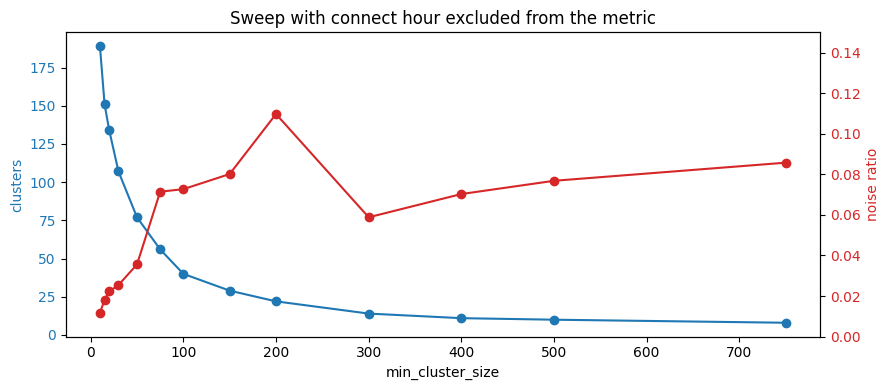

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(sweep2["min_cluster_size"], sweep2["n_clusters"], marker="o", color="tab:blue")
ax1.set_xlabel("min_cluster_size")
ax1.set_ylabel("clusters", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(sweep2["min_cluster_size"], sweep2["noise_ratio"], marker="o", color="tab:red")
ax2.set_ylabel("noise ratio", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax2.set_ylim(0, 0.15)

ax1.set_title("Sweep with connect hour excluded from the metric")
fig.tight_layout()
plt.show()

Two candidates. Noise hits a local low of 5.9% at min_cluster_size=300, which leaves 14 clusters. 500 gives 10 clusters at 7.7%. Taking 500: the extra 1.8 points of noise buys four fewer groups to account for, and at this stage every cluster still has to be read one by one. Worth revisiting if that reading turns out to need the finer split.

In [14]:
MIN_CLUSTER_SIZE_V2 = 500

labels_v2 = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE_V2, copy=False).fit_predict(Xw)
sessions["cluster"] = labels_v2
sessions["is_noise"] = labels_v2 == -1
sessions["cluster"].value_counts().sort_index()

cluster
-1     1729
 0     1331
 1      913
 2     1257
 3     1391
 4     1658
 5     1406
 6      613
 7    10024
 8     1093
 9     1096
Name: count, dtype: int64

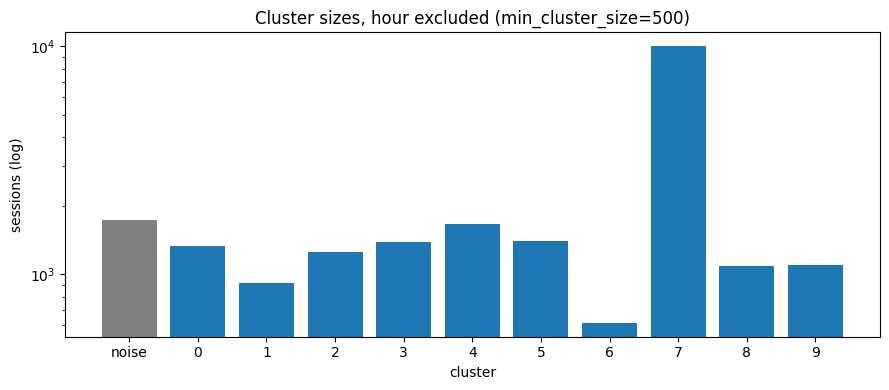

In [15]:
sizes = sessions["cluster"].value_counts().sort_index()
colors = ["gray" if c == -1 else "tab:blue" for c in sizes.index]
labels_x = ["noise" if c == -1 else str(c) for c in sizes.index]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(labels_x, sizes.values, color=colors)
ax.set_yscale("log")
ax.set_xlabel("cluster")
ax.set_ylabel("sessions (log)")
ax.set_title(f"Cluster sizes, hour excluded (min_cluster_size={MIN_CLUSTER_SIZE_V2})")
fig.tight_layout()
plt.show()

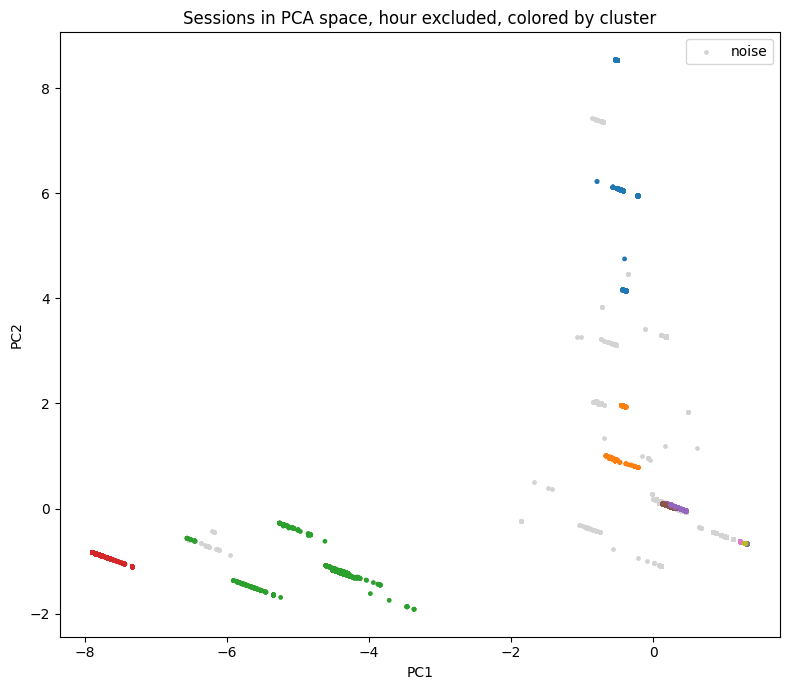

In [16]:
coords = PCA(n_components=2).fit_transform(Xw)
sessions["pca_1"] = coords[:, 0]
sessions["pca_2"] = coords[:, 1]

fig, ax = plt.subplots(figsize=(8, 7))
noise_mask = sessions["is_noise"]
ax.scatter(
    sessions.loc[noise_mask, "pca_1"], sessions.loc[noise_mask, "pca_2"],
    s=6, color="lightgray", label="noise",
)
clustered = sessions.loc[~noise_mask]
ax.scatter(
    clustered["pca_1"], clustered["pca_2"],
    s=6, c=clustered["cluster"], cmap="tab10",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Sessions in PCA space, hour excluded, colored by cluster")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

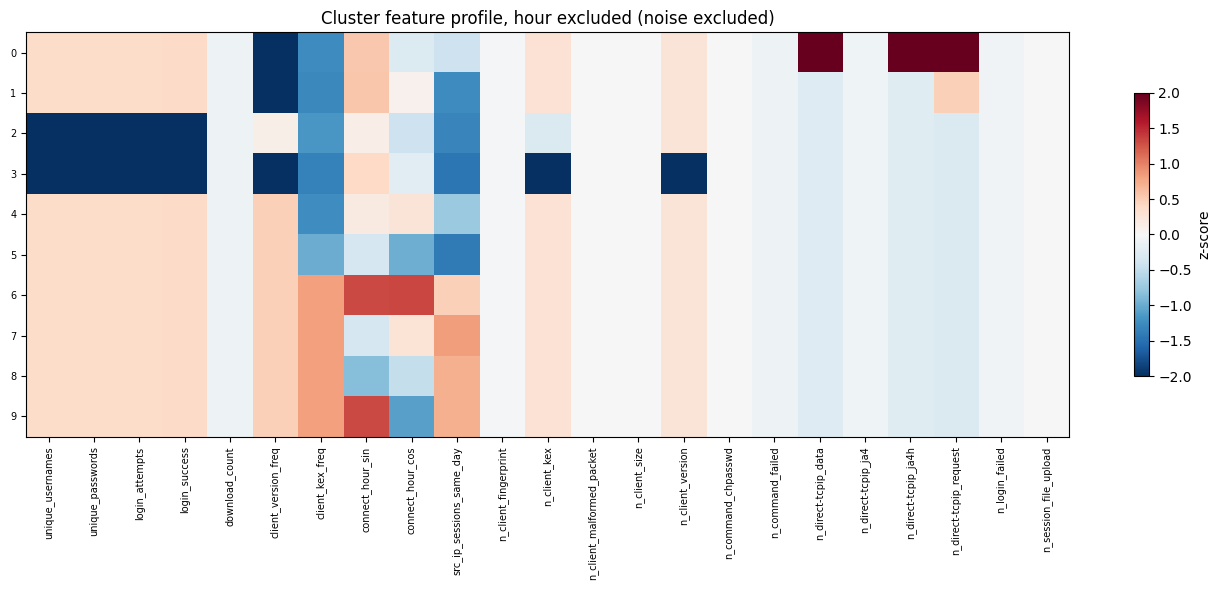

In [17]:
z2 = (X - X.mean()) / X.std()
z2["cluster"] = sessions["cluster"].values
profile2 = z2[z2["cluster"] != -1].groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(0.5 * len(profile2.columns) + 2, 0.4 * len(profile2) + 2))
im = ax.imshow(profile2.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(profile2.columns)))
ax.set_xticklabels(profile2.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(profile2.index)))
ax.set_yticklabels(profile2.index, fontsize=7)
fig.colorbar(im, shrink=0.7, label="z-score")
ax.set_title("Cluster feature profile, hour excluded (noise excluded)")
fig.tight_layout()
plt.show()

Ten clusters, and what they are made of matters more than how many there are.

Four of them (6, 7, 8 and 9, together 12,826 sessions, 57% of the dataset) come entirely from one /24. They are identical on every behavioural column: login always succeeds, one command, no tunnel, no download. What separates them is `src_ip_sessions_same_day`, whose median runs 622, 1437, 1096, 1099 across the four. That column is not behaviour, it is which source and which day a session came from, so this is a single campaign cut into four by its own daily volume.

The rest do read as behaviour. Cluster 3 has no client handshake at all, cluster 2 handshakes but never attempts a login, cluster 0 logs in and then uses `direct-tcpip` tunnels without typing anything, and clusters 1, 4 and 5 differ in how far into the login-and-one-command pattern they get.

03 stratifies on this, but the four-way split of one campaign is the thing to fix before the labels mean much.

In [18]:
out_path = out_dir / "sessions_clustered.parquet"
sessions.to_parquet(out_path, index=False)
print(f"wrote {len(sessions)} rows, {sessions['cluster'].nunique() - 1} clusters, "
      f"{sessions['is_noise'].mean():.1%} noise, to {out_path}")

wrote 22511 rows, 10 clusters, 7.7% noise, to /data/work/sessions_clustered/sessions_clustered.parquet
